In [ ]:
import pandas as pd
import numpy as np

meta = pd.read_csv(r'metacritic.csv')
hltb = pd.read_csv(r'hltb_dataset_filtered.csv')
gamfaqs =  pd.read_csv(r'gamefaqs_rankings.csv')

# after reading the files we drop the columns that are not needed and then merge them into one unified data set, this is the metacritic dataset
meta_dropped = meta.drop(columns=['id', 'platform', 'release_date', 'sort_no', 'summary'])
# dropped data columns from hltb data set
hltb_dropped = hltb.drop(columns=['id','platform','type','release_date', 'release_precision','release_month','release_day'
                                  ,'main_story_polled','main_plus_sides_polled','completionist_polled','all_styles_polled','single_player_polled'
                                  ,'co_op_polled','versus_polled','co_op','versus'])
#here we start merging the data set and save it to a new csv file
data_merged = pd.merge(gamfaqs, hltb_dropped, on = 'title')
data_merged = pd.merge(data_merged, meta_dropped, on = 'title') #unifed data set
data_merged.to_csv('merged_data.csv', index=False) # index false prevents pandas from labeling row numbers as a separate column

df = pd.read_csv(r'C:\Users\Aurelius\Desktop\School Projects\Data Science\VG_prediction engine\VG_prediction engine\csv files\merged_data.csv')
df = df.drop(columns=['co_op', 'versus'], errors='ignore')
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce') # some of the rows in user score had 'tbd', this forces it to be a number


numeric_scores = df.groupby('title')[['metascore', 'user_score']].mean().reset_index()  # averages metascores to help fill in values
game_details = df.drop(columns=['metascore', 'user_score'])
# Drop duplicates to keep one entry per title
game_details =game_details.drop_duplicates(subset=['title'], keep='first')
# Merge the de-duplicated details with the new average scores
final_data = pd.merge(game_details, numeric_scores, on='title')


# we separate columns from numeric and string values in this part
numeric_cols = final_data.select_dtypes(include=np.number).columns
categorical_cols = final_data.select_dtypes(include='object').columns # some categorical data had missing values so we need to select them too

#Fills numeric NaNs with the median of each column
final_data[numeric_cols] = final_data[numeric_cols].fillna(final_data[numeric_cols].median()) 

# Fills categorial NaNs with the string "Unknown"
final_data[categorical_cols] = final_data[categorical_cols].fillna("Unknown") # 

# no more nulls
cleaned_final_data = final_data
# there were some spots marked with unknown so this line removes it
cleaned_final_data = cleaned_final_data[cleaned_final_data['length'] != 'Unknown'].copy() # removes rows with unknown

# lower cases all title names so that we can sort the data titles alphabettically and prints out the cleaned data
cleaned_final_data.loc[:, 'title'] = cleaned_final_data['title'].str.lower() #.loc is a better way to modify data to avoid a pandas warning
# Sort alphabetically by title
cleaned_final_data = cleaned_final_data.sort_values(by='title')

# puts our cleaned data set into a new csv file
cleaned_final_data.to_csv('final_cleaned_data.csv', index=False)



In [1]:
import pandas as pd
import numpy as np
# purpose of this entire cell is to implement multi-hot encoding for genres, so is using a varient of the separate linear regressions
#One-hot encoding for platforms
# missing values are filled with median/mean and dropping title column since it wont be much use for linear regression


df = pd.read_csv('final_cleaned_data.csv')


# This step transforms the 'genres' column (which contains comma-separated genre values) into separate binary columns.
genres_df = df['genres'].str.get_dummies(sep=',') 
genres_df.columns = genres_df.columns.str.strip() # Strip any extra spaces in the genre column names (in case there are spaces after commas)
genres_df = genres_df.T.groupby(genres_df.columns).sum().T # Group by genre columns and sum them, ensuring any multiple occurrences of the same genre are counted
df = pd.concat([df, genres_df], axis=1)

# Drop the original 'genres' and the 'Unknown' genre column
if 'Unknown' in genres_df.columns:
    df = df.drop(columns=['genres', 'Unknown'])
else:
    df = df.drop(columns=['genres'])


# creates a list of major game publishers to identify whether each row corresponds to a major publisher.
major_publishers = [
    'Nintendo', 'Electronic Arts', 'Sony', 'Activision', 
    'Ubisoft', 'Microsoft', 'BANDAI NAMCO Entertainment', 'Sega'
] # Creates a new binary column, 'is_major_publisher', where 1 means the publisher is one of the major publishers, else 0
df['is_major_publisher'] = df['publisher'].isin(major_publishers).astype(int)
df = df.drop(columns=['developer', 'publisher']) # Drop the 'developer' and 'publisher' columns, as they've been transformed or aren't needed for modeling

# Convert the 'platform' column into binary columns, one for each platform. 
df = pd.get_dummies(df, columns=['platform'], drop_first=True) # use drop_first=True to avoid creating redundant columns 


df['length'] = pd.to_numeric(df['length'], errors='coerce') # Convert the 'length' column to numeric, coercing any invalid values to NaN.
df['length'] = df['length'].fillna(df['length'].median())# Fill any missing 'length' values (NaNs) with the median length of all records


df = df.drop(columns=['title'])


# Save the final, model-ready data
df.to_csv('engineered_data.csv', index=False)

In [ ]:
import pandas as pd

# Purpose of this cell is to merge genre columns, validate combined genres, 
# drop unnecessary columns, and output a cleaned and validated DataFrame.

# define the raw strings and columns to drop
raw_string = r"Http://Prinnies.Com/"
columns_to_drop = ['3-D', '4X', 'Artillery', raw_string, 'Full Motion Video (Fmv)', 'Pub Games']

# maps all target genre names to the list of raw genres they encompass
genre_mapping = {
    'Platformer': ['Platform', 'Platforming', 'Platformer', 'Cinematic Platformer', 'Action/Platform'],
    'Point-And-Click': ['Point-And-Click', 'Point-And-Click Adventure'],
    'Wrestling': ['Professional Wrestling', 'Professional Wrestling Fighting', 'Wrestling'],
    'Puzzle': ['Puzzle', 'Puzzle Game', 'Puzzle Rpg', 'Breakout', 'Maze', 'Mystery'],
    'RTS': ['Real Time Strategy', 'Real-Time Tactical Rpg', 'Real-Time Tactics', 'Historical Real-Time'],
    'Rhythm': ['Rhythm', 'Rhythm Game', 'Music/Rhythm'],
    'Vehicular Combat': ['Vehicular Combat', 'Vehicle Combat', 'Car Combat'],
    'Turn-Based': ['Turn-Based', 'Turn-Based Role-Playing', 'Turn-Based Tactics'],
    'Third-Person Shooter': ['Third-Person Shooter Sandbox', 'Third-Person Shooter'],
    'Third-Person Action Adventure': ['Third-Person Action Adventure', 'Third-Person Action-Adventure'],
    'Tactical RPG': ['Tactical Role-Playing', 'Tactical Rpg'],
    'Strategy': ['Strategy', 'Strategy/Tactical'],
    'Stealth': ['Stealth-Based Game', 'Stealth'],
    'Sports': ['Sports', 'Sport', 'American Football'],
    'Space Combat Simulation': ['Space Combat Simulator', 'Space Simulation', 'Space Combat Sim'],
    'Shoot-Em-Up': ['Shoot-Em-Up', "Shoot 'Em Up", 'Vertical Scrolling Shooter'],
    'ARPG': ['Action Role-Playing', 'Action Role-Playing Game', 'Action Rpg'],
    'Beat-Em-Up': ['Beat Em Up', 'Beat-Em-Up', 'Brawler'],
    'Card Game': ['Card', 'Card Battle', 'Card Game', 'Collectible Card Game'],
    'City Building': ['City-Building', 'City-Building Game'],
    'Aerial Combat': ['Aerial Combat', 'Combat Flight Simulator', 'Flight Combat'],
    'Simulation(Business)': ['Business Simulation Game', 'Construction And Management Simulation', 'Farm Simulation'],
    'Dungeon Crawler': ['Dungeon Crawl', 'Dungeon Crawler'],
    'Educational': ['Educational', 'Edutainment'],
    'Fighting': ['Fighting', 'Fighting Action', 'Fighting Game', 'Versus Fighting'],
    'FPS': ['First Person Shooter', 'First-Person Shooter'],
    'Fitness': ['Fitness', 'Exercise'],
    'Simulation(Flight)': ['Flight Simulation', 'Flight Simulator'],
    'Hack and Slash': ['Hack And Slash', 'Hack-And-Slash'],
    'Light Gun Shooter': ['Light Gun', 'Light Gun Shooter'],
    'Game Compilation': ['Compilation', 'Mini-Game Compilation', 'Minigames'],
    'Party Game': ['Party', 'Family Games'],
    'RPG': ['Role Playing', 'Role-Playing', 'Role-Playing Game'],
    'Side Scroller': ['Scrolling', 'Side'],
    'Simulation(Vehicles)': ['Submarine Simulator', 'Vehicle Simulation', 'Mech Simulator'],
    'Arcade': ['Action Driving', 'Arcade'],
    'MultiDirectional Shooter': ['Multi-Directional Shooter', 'Multidirectional', 'Multidirectional Shooter'],
    'Shooter': ['Shooting', 'Shooter'],
    'Simulation(Dating or Life)': ['Date Simulation','Life Simulation Game', 'Medical Simulation'],
    'Interactive Art': ['Art Game', 'Interactive Art']
}

# functions for organizing and validating

def merge_columns(df, old_cols, new_col_name):
    #Merges multiple  genre columns into one and drops the old ones.
    existing_cols = [col for col in old_cols if col in df.columns]
    
    if existing_cols:
        df[new_col_name] = df[existing_cols].max(axis=1)
        df = df.drop(columns=existing_cols)
    else:
        df[new_col_name] = 0
        
    return df

def alphabetical_order(df):
    #Sorts ONLY the genre columns alphabetically, leaving other columns in place
    
    # 1. Get a list of our genre names (keys from the dictionary + 'Action')
    genres = list(genre_mapping.keys())
    if 'Action' in df.columns:
        genres.append('Action')
        
    # Keep only the genres that actually exist in the dataframe
    valid_genres = [g for g in genres if g in df.columns]
    sorted_genres = sorted(valid_genres)
    
    # gets all non-genre columns (Publishers, target scores, IDs, etc.)
    other_cols = [c for c in df.columns if c not in valid_genres]
    
    # put the dataframe back together: 
    # Front columns -> Sorted Genres -> The last 15 columns
    first_cols = other_cols[:-15]
    last_cols = other_cols[-15:]
    
    new_order = first_cols + sorted_genres + last_cols
    return df[new_order]

def validate_rows_with_genre(df, delete_rows=False):
    #Deletes rows that don't have a 1 in any of the known genre columns
    genres = list(genre_mapping.keys())
    if 'Action' in df.columns:
        genres.append('Action')
        
    valid_genres = [g for g in genres if g in df.columns]
    
    # creates mask checking if row has at least one '1' in the valid genre columns
    valid_rows_mask = (df[valid_genres] == 1).sum(axis=1) > 0
    
    if delete_rows:
        return df[valid_rows_mask]
    else:
        return df


# execution code block
df = pd.read_csv('engineered_data.csv')
new_df = df.copy()

# apply the merge_columns function using the mapping
for new_col_name, old_cols in genre_mapping.items():
    new_df = merge_columns(new_df, old_cols, new_col_name)

# drop any unused columns
for name in columns_to_drop:
    if name in new_df.columns:  
        new_df = new_df.drop(name, axis=1)

# sort and validate 
new_df = alphabetical_order(new_df)
new_df = validate_rows_with_genre(new_df, delete_rows=True)

# save final output
new_df.to_csv('cleaned_and_validated_genres.csv', index=False) 
#print('Finished')

Finished


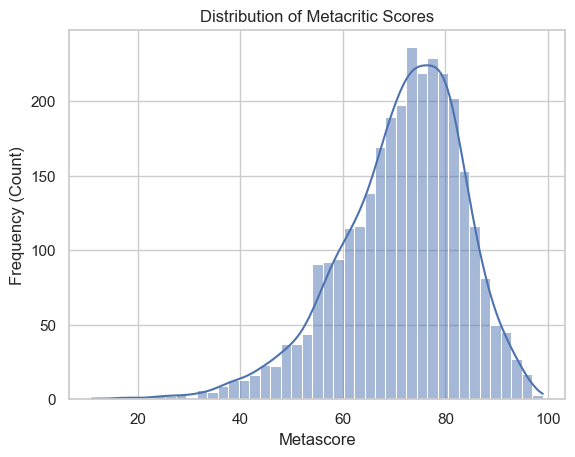

<Figure size 640x480 with 0 Axes>

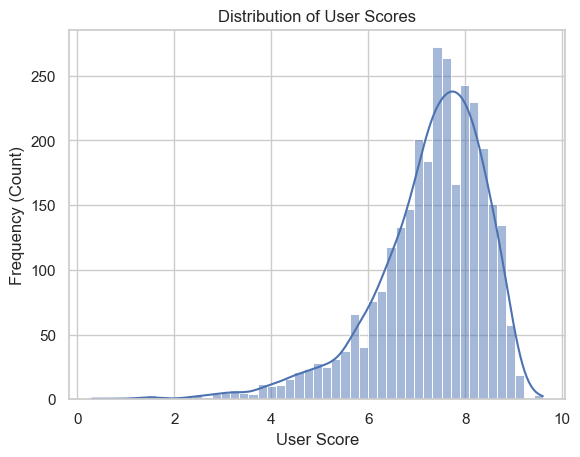

<Figure size 640x480 with 0 Axes>

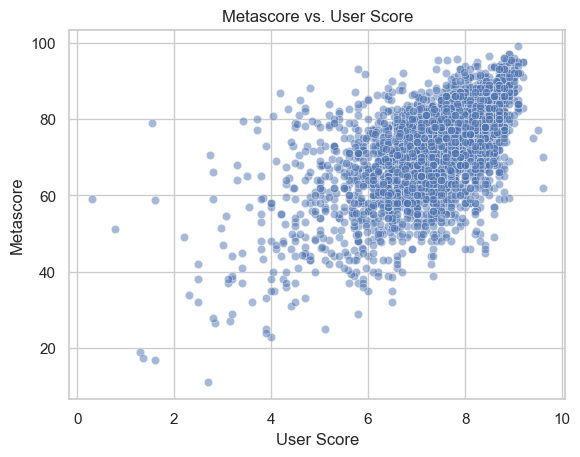

<Figure size 640x480 with 0 Axes>

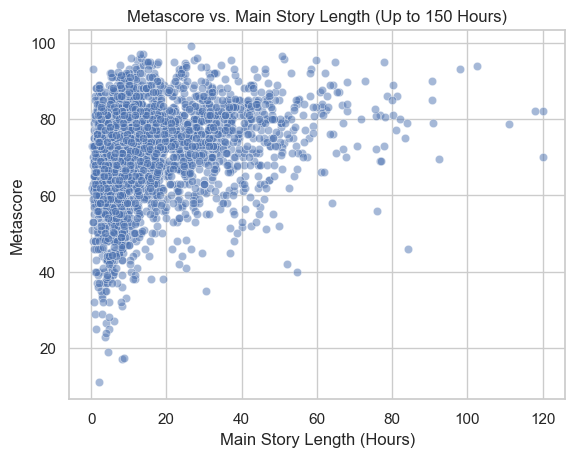

<Figure size 640x480 with 0 Axes>

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
df = pd.read_csv('cleaned_and_validated_genres.csv')

 #Plot 1: Histogram of metascore
plt.figure() 
sns.histplot(data=df, x='metascore', kde=True)
plt.title('Distribution of Metacritic Scores')
plt.xlabel('Metascore')
plt.ylabel('Frequency (Count)')
#plt.savefig('metascore_histogram.png') 
plt.show()
plt.clf() # Clears the plot, so we can make a new one

#Plot 2: Histogram of UserScore 

plt.figure() 
sns.histplot(data=df, x='user_score', kde=True)
plt.title('Distribution of User Scores')
plt.xlabel('User Score')
plt.ylabel('Frequency (Count)')
#plt.savefig('user_histogram.png') 
plt.show()
plt.clf() 


#Plot 3: Scatter Plot (user_score vs. metascore) 
    
plt.figure() 
sns.scatterplot(data=df, x='user_score', y='metascore', alpha=0.5) # alpha adds transparency
plt.title('Metascore vs. User Score')
plt.xlabel('User Score')
plt.ylabel('Metascore')
#plt.savefig('metascore_vs_userscore_scatter.png')
plt.show()
plt.clf() 

#Plot 4: Scatter Plot (main_story vs. metascore)
    
plt.figure() 
    # filtered out extreme outliers for a more readable plot
filtered_length = df[df['main_story'] <= 150] # Filter games to include length played <= 150 hours, was getting some crazy outliers
sns.scatterplot(data=filtered_length, x='main_story', y='metascore', alpha=0.5)
plt.title('Metascore vs. Main Story Length (Up to 150 Hours)')
plt.xlabel('Main Story Length (Hours)')
plt.ylabel('Metascore')
#plt.savefig('metascore_vs_mainstory_scatter.png')
plt.show()
plt.clf()





In [ ]:
import pandas as pd
import numpy as np
   
model_df = pd.read_csv('cleaned_and_validated_genres.csv')
    # Generate descriptive statistics for ALL columns
stats = model_df.describe() #https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html
    # transposes the statistics to make it easier to read (columns become rows)
stats_transposed = stats.transpose()

relevant_cols = [
    'rating', 'dificulty', 'length', 'release_year', 'main_story',
    'main_plus_sides', 'completionist', 'all_styles', 'single_player',
    'metascore', 'user_score', 'is_major_publisher'
]


stats_to_print = stats_transposed.loc[relevant_cols]
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# this prints only the relevant subset
#print(stats_to_print)


                     count         mean         std      min      25%  \
rating              3037.0     3.554616    0.495065     0.70     3.29   
dificulty           3037.0     3.143480    0.489851     1.19     2.89   
length              3037.0    29.189420   18.978079     0.75    14.13   
release_year        3037.0  2010.875206    6.550043  1980.00  2006.00   
main_story          3037.0    17.098798   36.317410     0.17     5.70   
main_plus_sides     3037.0    28.533454   69.872989     0.32     9.13   
completionist       3037.0    54.636737  179.802582     0.40    15.00   
all_styles          3037.0    28.047968   76.242734     0.17     7.28   
single_player       3037.0    17.098798   36.317410     0.17     5.70   
metascore           3037.0    71.444286   11.988758    11.00    65.00   
user_score          3037.0     7.280663    1.162452     0.30     6.70   
is_major_publisher  3037.0     0.162002    0.368513     0.00     0.00   

                        50%      75%      max  
ra

Features (X) shape: (3037, 136)
Target (y) shape: (3037,)
Training set size: 2429 rows
Testing set size: 608 rows
R-squared (R²): 0.5077
Root Mean Squared Error (RMSE): 8.3145

--- Interpretation ---
Interpretation: Our model explains 50.77% of the variance and is off by ~8.31 points.

--- Feature Importance ---
Top 10 most influential features:
platform_WSC              22.686332
platform_NGPC             21.570712
platform_WIIU             18.996456
platform_C64              17.963743
platform_WII              15.106723
platform_NES              14.282342
Combat Simulation         14.210088
Strategy Side-Scroller    13.980234
platform_PSP              13.826513
platform_DC               13.568599
dtype: float64


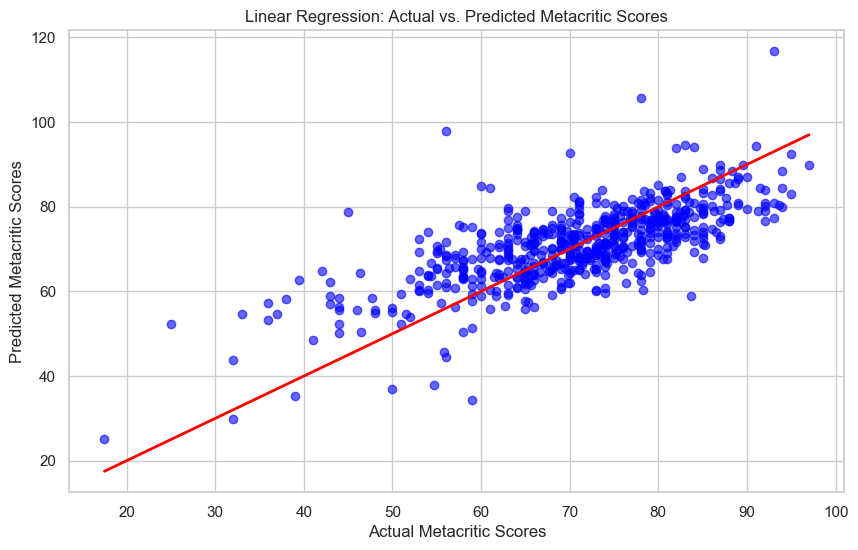

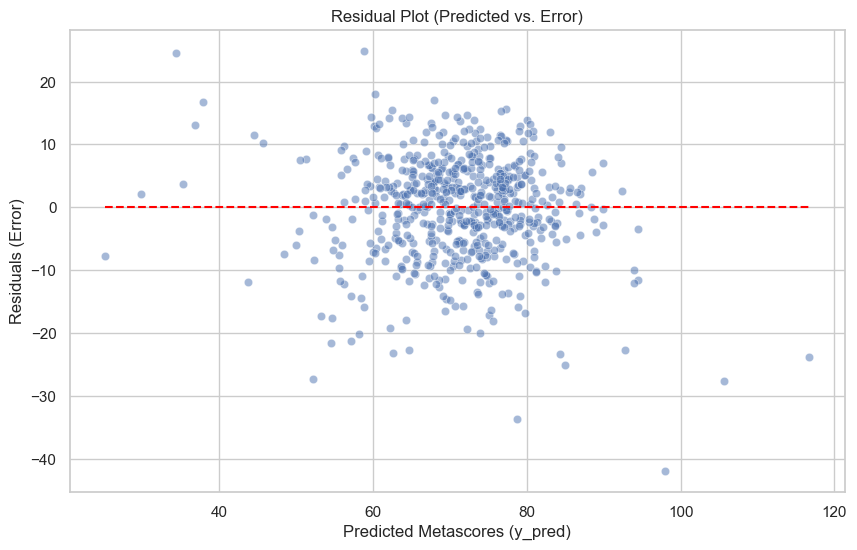

In [25]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('cleaned_and_validated_genres.csv')

# Define the target variable 'y' ,the column we want to predict
y = df['metascore']
    
# The features 'X' are all other columns except metascore and singleplayer.
#single player had to be excluded since it was messing with R^2 value
X = df.drop(columns=['metascore','single_player'])
    
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

#Split Data into Training and Testing Sets
# hold back 20% of the data to test the model, 80% will train model, the other 20% will be used to test it with unseen data
# random_state=42 ensures you get the same "random" split every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

model = LinearRegression()
# This is the line that builds the model
model.fit(X_train, y_train) 

y_pred = model.predict(X_test)
    # R-squared:
r2 = r2_score(y_test, y_pred)
    # Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

print("\n--- Interpretation ---")
print(f"Interpretation: Our model explains {r2*100:.2f}% of the variance and is off by ~{rmse:.2f} points.")

print("\n--- Feature Importance ---") 
coefficients = pd.Series(model.coef_, index=X.columns)
importance = coefficients.abs().sort_values(ascending=False)
    
print("Top 10 most influential features:")
print(importance.head(10))

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Linear Regression: Actual vs. Predicted Metacritic Scores')
plt.xlabel('Actual Metacritic Scores')
plt.ylabel('Predicted Metacritic Scores')
plt.grid(True)
plt.show()

residuals = y_test - y_pred
    
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)

plt.hlines(y=0, xmin=min(y_pred), xmax=max(y_pred), color='red', linestyle='--')
    
plt.xlabel('Predicted Metascores (y_pred)')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot (Predicted vs. Error)')
plt.show()

R-squared (R²): 0.5554
Root Mean Squared Error (RMSE): 7.9020
Interpretation: Our model explains 55.54% of the variance and is off by ~7.90 points.

--- Feature Importance (Top 10) ---
rating             0.390441
user_score         0.177391
release_year       0.069911
length             0.049066
dificulty          0.042610
completionist      0.036596
all_styles         0.035078
main_story         0.034387
main_plus_sides    0.032295
platform_PC        0.012379
dtype: float64


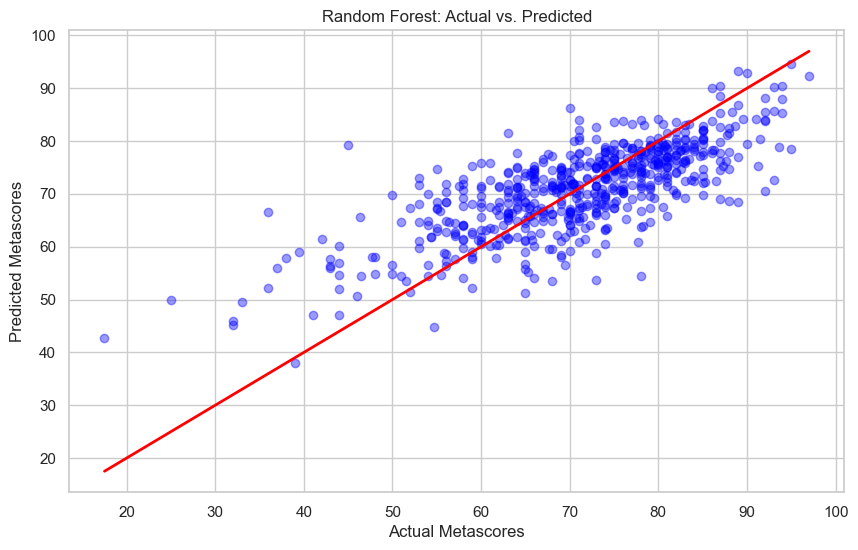

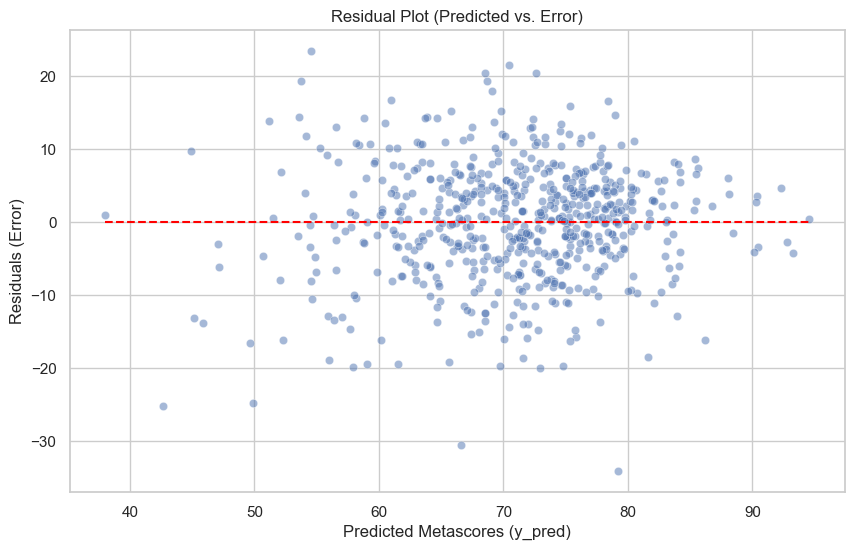

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_and_validated_genres.csv')
y = df['metascore']
X = df.drop(columns=['metascore', 'single_player'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) #100 = number of trees the higher the better but more computationally expensive
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Interpretation: Our model explains {r2*100:.2f}% of the variance and is off by ~{rmse:.2f} points.")

print("\n--- Feature Importance (Top 10) ---")

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(10)) 

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.4)
p1 = max(max(y_pred), max(y_test))
p2 = min(min(y_pred), min(y_test))
plt.plot([p1, p2], [p1, p2], color='red', linewidth=2)
plt.xlabel('Actual Metascores')
plt.ylabel('Predicted Metascores')
plt.title('Random Forest: Actual vs. Predicted')
plt.show()

residuals = y_test - y_pred
    
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)

plt.hlines(y=0, xmin=min(y_pred), xmax=max(y_pred), color='red', linestyle='--')
    
plt.xlabel('Predicted Metascores (y_pred)')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot (Predicted vs. Error)')
plt.show()

R-squared (R²): 0.5768
Root Mean Squared Error (RMSE): 7.7094
Interpretation: Our model explains 57.68% of the variance and is off by ~7.71 points.

--- Feature Importance (Top 10) ---
user_score       0.047347
rating           0.039984
Third-Person     0.032125
platform_PC      0.026715
platform_PSP     0.026707
platform_ARC     0.023923
platform_WIIU    0.022969
platform_LNX     0.019662
platform_PS2     0.019554
platform_XONE    0.018595
dtype: float32


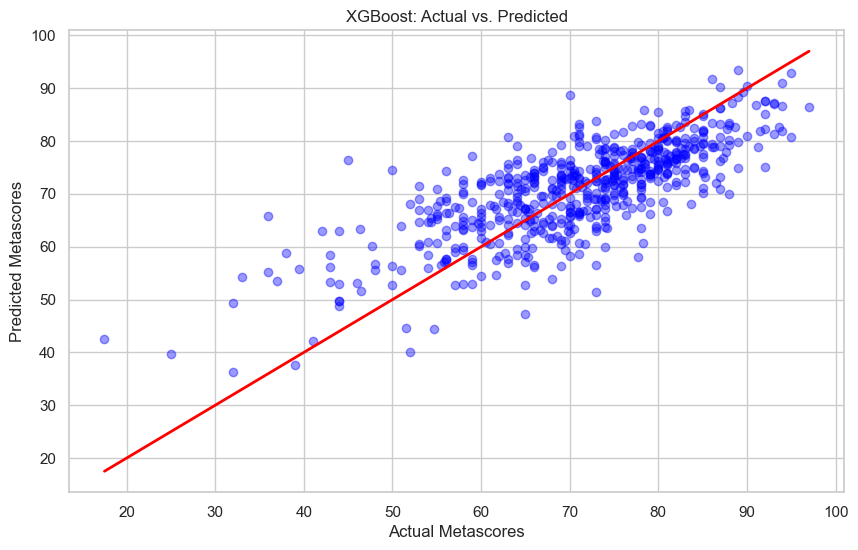

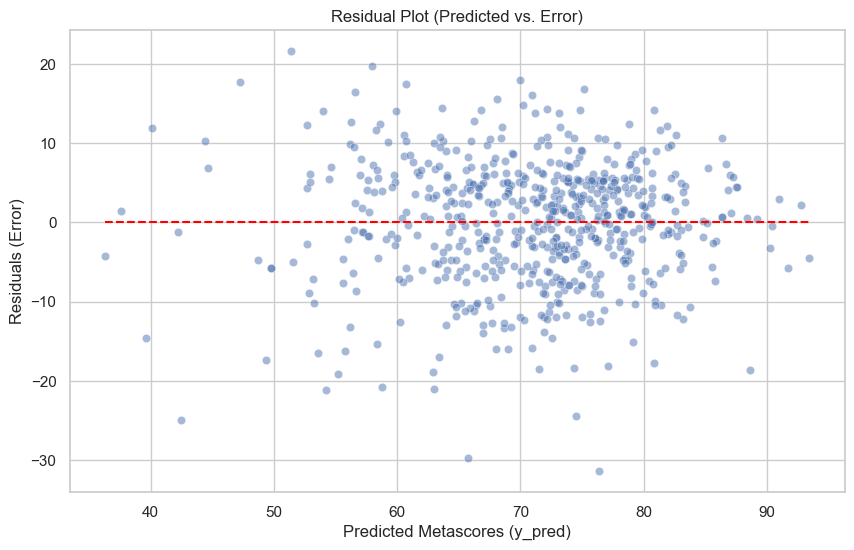

In [ ]:
# # The purpose of this cell is to train and evaluate an XGBoost regression model
# to predict video game Metacritic scores The script splits the dataset into training and testing sets, trains an
# XGBoost model, and evaluates its predictive performance using R² and RMSE.
# It then analyzes the model by identifying the most important features and
# visualizing model performance with Actual vs. Predicted and residual plots
# to assess prediction accuracy and error patterns.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor


df = pd.read_csv("cleaned_and_validated_genres.csv")

y = df["metascore"]
X = df.drop(columns=["metascore", "single_player"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost Model

xgb_model = XGBRegressor(
    n_estimators=300,       # number of boosting rounds
    learning_rate=0.05,     # step size
    max_depth=6,            # tree depth
    subsample=0.8,          # row sampling
    colsample_bytree=0.8,   # feature sampling
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

# Evaluation

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Interpretation: Our model explains {r2*100:.2f}% of the variance "
      f"and is off by ~{rmse:.2f} points.")


# Feature Importances

print("\n--- Feature Importance (Top 10) ---")
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(10))


# Plot: Actual vs Predicted

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.4)

p1 = max(max(y_pred), max(y_test))
p2 = min(min(y_pred), min(y_test))
plt.plot([p1, p2], [p1, p2], color="red", linewidth=2)

plt.xlabel("Actual Metascores")
plt.ylabel("Predicted Metascores")
plt.title("XGBoost: Actual vs. Predicted")
plt.show()


# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.hlines(y=0, xmin=min(y_pred), xmax=max(y_pred), color="red", linestyle="--")

plt.xlabel("Predicted Metascores (y_pred)")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot (Predicted vs. Error)")
plt.show()


In [ ]:
#The purpose of this cell is to train a Linear Regression model on historical
# video game data.

# After training, the model generates a prediction for a hypothetical game
# configuration representing Call of Duty: Black Ops 7. The script then
# decomposes the prediction into its individual feature contributions using
# the linear regression coefficients, showing exactly how each feature
# increases or decreases the predicted score relative to the model's intercept.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('cleaned_and_validated_genres.csv')

# Prepare Data
cols_to_drop = ['metascore', 'single_player']
if 'user_score' in df.columns:
    cols_to_drop.append('user_score')
if 'Unnamed: 0' in df.columns:
    cols_to_drop.append('Unnamed: 0')

y = df['metascore']
X = df.drop(columns=cols_to_drop, errors='ignore')

# Train Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# PREDICTION FOR BLACK OPS 7

# Creates Template Row (Averages from training set)
bo7_features = pd.DataFrame([X_train.mean()], columns=X.columns)

# Define Known Specs
known_specs = {
    'Action': 1, 
    'Shooter': 1, 
    'FPS': 1, 
    'First-Person': 1,
    'is_major_publisher': 1, 
    'release_year': 2025,
    'platform_PC': 1, 
    'platform_PS5': 1, 
    'platform_XBSX': 1,
    'main_story': 7, 
}

# Apply Specs
for col, val in known_specs.items():
    if col in bo7_features.columns:
        bo7_features[col] = val

#  Make Prediction
predicted_score = lr_model.predict(bo7_features)[0]

#  Generate Report
print("\n" + "="*60)
print(f"LINEAR REGRESSION REPORT: Call of Duty: Black Ops 7")
print("="*60)
print(f"Predicted Metascore: {predicted_score:.2f}")
print("-" * 60)

#  Exact Score Breakdown
# Linear Regression is just: Score = Intercept + (Coef1 * Val1) + (Coef2 * Val2)...
intercept = lr_model.intercept_

print(f"Base Score (Intercept):  {intercept:.2f}")
print("Feature Adjustments:")

contributions = []
for col in bo7_features.columns:
    val = bo7_features[col].values[0]
    # Handle cases where feature might not exist in model (rare)
    if col in X.columns:
        idx = X.columns.get_loc(col)
        coef = lr_model.coef_[idx]
        impact = val * coef
        
        # Only show things that actually moved the needle (> 0.1 points)
        if abs(impact) > 0.1:
            contributions.append((col, val, coef, impact))

# Sort by impact magnitude (biggest changers first)
contributions.sort(key=lambda x: abs(x[3]), reverse=True)

# Print Top Influencers
for col, val, coef, impact in contributions: 
    sign = "+" if impact > 0 else ""
    # Formatting: "Shooter (1 * 2.5) = +2.5"
    print(f" {sign}{impact:.2f} pts | {col:<20} (Value: {val} * Coef: {coef:.2f})")

print("-" * 60)
print(f"Final Sum: {intercept:.2f} + ({sum(c[3] for c in contributions):.2f}) = {predicted_score:.2f}")


LINEAR REGRESSION REPORT: Call of Duty: Black Ops 7
Predicted Metascore: 85.84
------------------------------------------------------------
Base Score (Intercept):  36.49
Feature Adjustments:
 +58.52 pts | rating               (Value: 3.5562577192260196 * Coef: 16.46)
 -23.22 pts | release_year         (Value: 2025 * Coef: -0.01)
 +4.99 pts | platform_XBSX        (Value: 1 * Coef: 4.99)
 +4.46 pts | platform_PS5         (Value: 1 * Coef: 4.46)
 +2.66 pts | is_major_publisher   (Value: 1 * Coef: 2.66)
 +2.48 pts | FPS                  (Value: 1 * Coef: 2.48)
 -1.57 pts | length               (Value: 29.161972004940306 * Coef: -0.05)
 +1.41 pts | dificulty            (Value: 3.148036228900782 * Coef: 0.45)
 +0.89 pts | Action               (Value: 1 * Coef: 0.89)
 +0.79 pts | main_plus_sides      (Value: 27.49371346233018 * Coef: 0.03)
 -0.69 pts | all_styles           (Value: 27.16004116920543 * Coef: -0.03)
 +0.54 pts | First-Person         (Value: 1 * Coef: 0.54)
 -0.33 pts | platfor

In [ ]:
# The purpose of this block is to train a Random Forest model on historical video game
# data to predict a game's critic metascore based on its features and
# uses SHAP values to explain which features most influenced the prediction.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap


df = pd.read_csv('cleaned_and_validated_genres.csv')

# prepares features, drops 'user_score', we're trying to predict critic score
cols_to_drop = ['metascore', 'single_player', 'user_score']
if 'Unnamed: 0' in df.columns:
    cols_to_drop.append('Unnamed: 0')

y = df['metascore']
X = df.drop(columns=cols_to_drop)

#training the random forest model, 20% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model_clean = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_clean.fit(X_train, y_train)

# --- PREDICTION FOR BLACK OPS 7 ---

#row averages
bo7_features = pd.DataFrame([X_train.mean()], columns=X.columns)

#Define Known Specs
specs = {
    'Action': 1, 
    'Shooter': 1, 
    'FPS': 1, 
    'First-Person': 1,
    'is_major_publisher': 1, 
    'release_year': 2025,
    'platform_PC': 1, 
    'platform_PS5': 1, 
    'platform_XBSX': 1,
    'main_story': 7, 
}

# apply specs
for col, val in specs.items():
    if col in bo7_features.columns:
        bo7_features[col] = val

# Predict (Main Model)
predicted_score = rf_model_clean.predict(bo7_features)[0]

#  convert to .values to avoid the "feature names" warning
bo7_raw_values = bo7_features.values 
tree_predictions = [tree.predict(bo7_raw_values)[0] for tree in rf_model_clean.estimators_]

min_pred = np.min(tree_predictions)
max_pred = np.max(tree_predictions)
std_dev = np.std(tree_predictions)

bo7_raw_values = bo7_features.values
tree_predictions = [tree.predict(bo7_raw_values)[0] for tree in rf_model_clean.estimators_]


# 90% Interval = We keep the middle 90% of votes (from 5th percentile to 95th)
lower_bound = np.percentile(tree_predictions, 5)
upper_bound = np.percentile(tree_predictions, 95)

lower_95 = np.percentile(tree_predictions, 2.5)
upper_95 = np.percentile(tree_predictions, 97.5)


print("\n" + "-"*40)
print(f"PREDICTION REPORT: Call of Duty: Black Ops 7")
print("-"*40)
print(f"Predicted Score: {np.mean(tree_predictions):.1f}")
print(f"90% Prediction Interval: {lower_bound:.1f} - {upper_bound:.1f}")
print("-" * 40)
print(f"Interpretation:")
print(f"While one tree might have guessed {min(tree_predictions):.1f} (Min) or {max(tree_predictions):.1f} (Max),")
print(f"90% of the model's decision paths agree the score will land between {lower_bound:.1f} and {upper_bound:.1f}.")
print("-"*40)
print(f"Standard Deviation: {std_dev:.2f}")
print("-"*40)

print("\nInterpretation:")
# depending on std, we can judge the uncertainty
if std_dev > 10:
    print("The model is very uncertain (High Std Dev). The trees disagree significantly.")
elif std_dev < 5:
    print("The model is very confident (Low Std Dev). Most trees agree.")
else:
    print("The model is moderately confident.")

# --- SHAP ANALYSIS ---
print("\n" + "="*60)
print("SHAP ANALYSIS: Why did the model predict this score?")
print("="*60)

# create object that can calculate shap values
explainer = shap.TreeExplainer(rf_model_clean)
shap_values = explainer.shap_values(bo7_features)

# in regression, shap_values is just an array. We take the first (and only) row.
if isinstance(shap_values, list): 
    vals = shap_values[0]
else:
    vals = shap_values[0] # The values for the single row we predicted
    
base_value = explainer.expected_value
# If expected_value is an array (multi-output), take first
if isinstance(base_value, np.ndarray):
    base_value = base_value[0]
    
print(f"Base Value (Average Game Score): {base_value:.2f}")
print(f"Model Prediction:                {predicted_score:.2f}")
print("-" * 60)
print("Top Features pushing the score UP (+):")

# combine feature names and values
feature_names = X.columns
feature_importance = pd.DataFrame(list(zip(feature_names, vals)), columns=['col_name', 'shap_value'])

# sort by magnitude
feature_importance['abs_val'] = feature_importance['shap_value'].abs()
feature_importance = feature_importance.sort_values(by='abs_val', ascending=False)

# displays top 5 UP and top 5 DOWN feature importances
top_positive = feature_importance[feature_importance['shap_value'] > 0].head(5)
top_negative = feature_importance[feature_importance['shap_value'] < 0].head(5)

for index, row in top_positive.iterrows():
    print(f" + {row['col_name']:<20} (+{row['shap_value']:.2f})")
    
print("\nTop Features dragging the score DOWN (-):")
for index, row in top_negative.iterrows():
    print(f" - {row['col_name']:<20} ({row['shap_value']:.2f})")
# printing results    
print("-" * 60)
print("Total Impact: The sum of these +/- values equals the difference")
print("between the Base Value and the Prediction.")

c:\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



----------------------------------------
PREDICTION REPORT: Call of Duty: Black Ops 7
----------------------------------------
Predicted Score: 76.6
90% Prediction Interval: 63.0 - 88.0
----------------------------------------
Interpretation:
While one tree might have guessed 57.0 (Min) or 93.0 (Max),
90% of the model's decision paths agree the score will land between 63.0 and 88.0.
----------------------------------------
Standard Deviation: 6.94
----------------------------------------

Interpretation:
The model is moderately confident.

SHAP ANALYSIS: Why did the model predict this score?
Base Value (Average Game Score): 71.59
Model Prediction:                76.56
------------------------------------------------------------
Top Features pushing the score UP (+):
 + release_year         (+1.35)
 + platform_PC          (+0.96)
 + FPS                  (+0.59)
 + First-Person         (+0.33)
 + dificulty            (+0.29)

Top Features dragging the score DOWN (-):
 - main_story      